# Single-column terrain-following firn model

The computational vertical coordinate is

$$
\zeta\in[0,1],
$$

with $\zeta=0$ at the firn base and $\zeta=1$ at the surface. Define

$$
p=h\omega,
$$

where $h$ is the firn thickness and $\omega=D\zeta/Dt$.

The model is

$$
\partial_t(h\rho)+\partial_\zeta(\rho p)=0,
$$

$$
\partial_t h
=
a_s-a_b
-h\int_0^1\frac{C}{\rho}\,d\zeta,
$$

$$
\partial_t h+\partial_\zeta p+h\frac{C}{\rho}=0,
$$

with

$$
p(1)=-a_s.
$$

This is imposed as a Dirichlet boundary condition; $p(0)=-a_b$ enters via the mass-flux residual.

The densification law is

$$
C=c\,a_s(\rho_i-\rho).
$$

Spatial discretization:

- density $\rho$: vertically discontinuous $DG_0$;
- thickness $h$: one real-valued degree of freedom;
- vertical flux $p$: vertically continuous $CG_1$.

Time is discretized with backward Euler. Density transport uses first-order upwinding across vertical cell interfaces.

In [1]:
from firedrake import *

import numpy as np
import matplotlib.pyplot as plt
from irksome import BackwardEuler, Dt, MeshConstant, TimeStepper

In [2]:
rho_i_value = 917.0 # ice density, kg m^-3
rho_s_value = 300.0 # surface density, kg m^-3
rho_b_target = 830.0 # target basal density, kg m^-3

a_s_value = 0.30 # surface accumulation, m yr^-1

temperature = 243.15 # K
gas_constant = 8.314 # J mol^-1 K^-1

c_value = 11.0 * np.exp(-10160.0 / (gas_constant * temperature))

lambda_target = np.log(
    rho_b_target * (rho_i_value - rho_s_value)
    / (rho_s_value * (rho_i_value - rho_b_target))
)

h_target = (lambda_target * rho_s_value / (c_value * rho_i_value))

# Steady mass-flux compatibility:
# rho_s * a_s = rho_b * a_b
a_b_value = rho_s_value * a_s_value / rho_b_target

print(f"c = {c_value:.8f} m^-1")
print(f"h target = {h_target:.8f} m")
print(f"a_b = {a_b_value:.8f} m yr^-1")

c = 0.07222612 m^-1
h target = 13.48275644 m
a_b = 0.10843373 m yr^-1


In [21]:
n_vertical = 100
rho_degree = 0

base_mesh = UnitIntervalMesh(1)

mesh = ExtrudedMesh(base_mesh, layers=n_vertical,layer_height=1.0 / n_vertical)

zeta_axis = mesh.geometric_dimension - 1
zeta = SpatialCoordinate(mesh)[zeta_axis]

V_rho = FunctionSpace(mesh, "DG", 0, vfamily="DG", vdegree=rho_degree)

V_h = FunctionSpace(mesh, "DG", 0, vfamily="R", vdegree=0)

V_p = FunctionSpace(mesh, "DG", 0, vfamily="CG", vdegree=rho_degree+1) # density is the discontinuous deriv. of cts p field

W = V_rho * V_h * V_p

state = Function(W, name="firn_state")
state_old = Function(W, name="firn_state_old")

rho_f, h_f, p_f = state.subfunctions

rho_i = Constant(rho_i_value)
rho_s = Constant(rho_s_value)
a_s = Constant(a_s_value)
a_b = Constant(a_b_value)
c = Constant(c_value)

lam = c_value * h_target * rho_i_value / rho_s_value

# initalize from a perturbation of cts steady state
rho_reference = (rho_i_value * rho_s_value/ (rho_s_value + (rho_i_value - rho_s_value) * exp(-lam * (1.0 - zeta))))

rho_f.interpolate(rho_reference * (1.0 + 0.05 * sin(pi * zeta)))

h_f.assign(h_target)

p_f.interpolate(-rho_s * a_s / rho_reference)

state_old.assign(state)

# save initial profile for plotting
rho_initial = rho_f.dat.data_ro.copy()

print(f"rho degrees of freedom: {V_rho.dim()}")
print(f"h degrees of freedom: {V_h.dim()}")
print(f"p degrees of freedom: {V_p.dim()}")

rho degrees of freedom: 100
h degrees of freedom: 1
p degrees of freedom: 101


In [22]:
rho, h, p = split(state)
phi, eta, psi = TestFunctions(W)

C = c * a_s * (rho_i - rho)
fractional_compaction = C / rho

normal = FacetNormal(mesh)

# flux thru each interior horiz facet, oriented outward from the "+" cell
normal_speed = (
    p("+") * normal[zeta_axis]("+")
)

# upwind. note at surf p < 0 means material enters col
rho_upwind = conditional(normal_speed >= 0.0, rho("+"),rho("-"))

F_rho = (
    Dt(h * rho) * phi * dx

    # cell interior transport; with rho in DG0 phi.dx is identically 0
    - rho * p * phi.dx(zeta_axis) * dx

    # interior numerical flux
    + (phi("+") - phi("-")) * normal_speed * rho_upwind * dS_h

    # Surface flux
    + rho_s * p * phi * ds_t

    # Basal flux
    - rho * p * phi * ds_b
)

F_h = (
    Dt(h) - a_s + a_b + h * fractional_compaction
) * eta * dx

F_p = (
    Dt(h) + p.dx(zeta_axis) + h * fractional_compaction
) * psi * dx

F = F_rho + F_h + F_p

In [23]:
MC = MeshConstant(mesh)

time = MC.Constant(0.0)
dt = MC.Constant(500.0)

bc_p_surface = DirichletBC(W.sub(2),-a_s,"top",)

solver_parameters = {
    "mat_type": "nest",

    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-10,
    "snes_atol": 1.0e-11,
    "snes_max_it": 30,

    "ksp_type": "fgmres",
    "ksp_rtol": 1.0e-10,
    "ksp_atol": 1.0e-12,
    "ksp_max_it": 300,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",

    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "lu",

    "fieldsplit_2_ksp_type": "gmres",
    "fieldsplit_2_ksp_rtol": 1.0e-10,
    "fieldsplit_2_pc_type": "none"
}

stepper = TimeStepper(
    F,
    BackwardEuler(),
    time,
    dt,
    state,
    bcs=[bc_p_surface],
    stage_type="value",
    solver_parameters=solver_parameters
)

In [24]:
final_time = 100000.0
print_every = 20

times = [0.0]
thickness = [float(h_f.dat.data_ro[0])]
mass_budget_errors = []

mass_old = assemble(h_f * rho_f * dx)

step = 0

while float(time) < final_time - 1.0e-12:
    remaining = final_time - float(time)

    if remaining < float(dt):
        dt.assign(remaining)

    dt_now = float(dt)

    stepper.advance()
    time.assign(float(time) + dt_now)

    step += 1

    mass_new = assemble(h_f * rho_f * dx)

    # outward mass flux at surface
    surface_flux = assemble(rho_s * p_f * ds_t)

    # outward mass flux at base
    basal_flux = assemble(-rho_f * p_f * ds_b)

    mass_budget_error = ((mass_new - mass_old) / dt_now + surface_flux + basal_flux)

    times.append(float(time))
    thickness.append(float(h_f.dat.data_ro[0]))
    mass_budget_errors.append(float(mass_budget_error))

    if step % print_every == 0:
        print(
            f"t = {float(time):7.1f} yr, "
            f"h = {thickness[-1]:9.5f} m, "
            f"rho = [{rho_f.dat.data_ro.min():7.2f}, "
            f"{rho_f.dat.data_ro.max():7.2f}]"
        )

    mass_old = mass_new

times = np.asarray(times)
thickness = np.asarray(thickness)
mass_budget_errors = np.asarray(mass_budget_errors)

t = 10000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 20000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 30000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 40000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 50000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 60000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 70000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 80000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 90000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]
t = 100000.0 yr, h =  13.47346 m, rho = [ 305.86,  830.00]


Final thickness = 13.4734640542 m
p(surface) + a_s = -5.551e-17
p(base) + a_b = 2.776e-16
Maximum mass-budget error = 9.948e-14


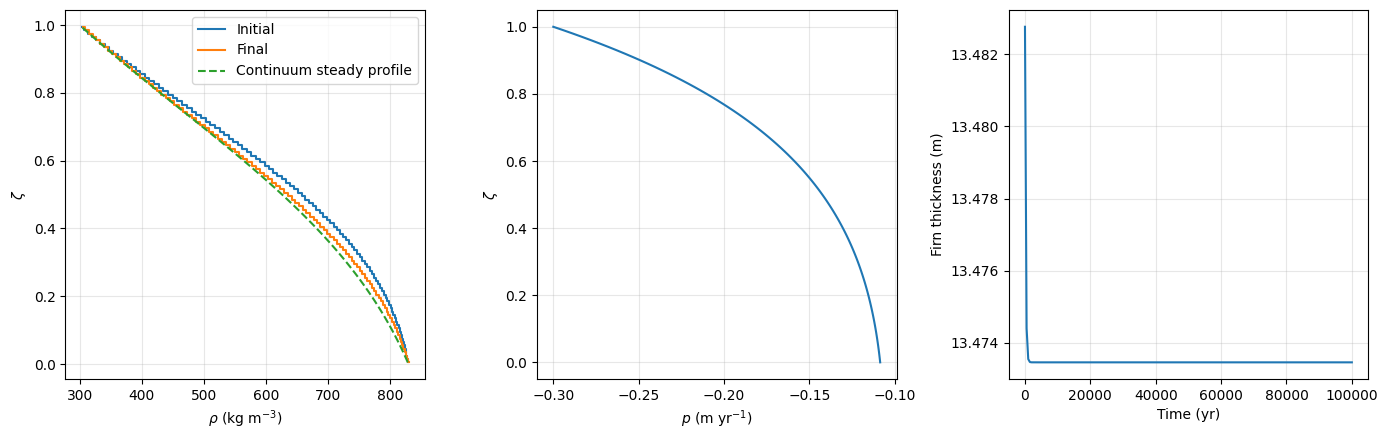

In [25]:
zeta_cells = (np.arange(n_vertical) + 0.5) / n_vertical

zeta_nodes = np.linspace(0.0,1.0,n_vertical + 1)

rho_final = rho_f.dat.data_ro.copy()
p_final = p_f.dat.data_ro.copy()

rho_target_plot = (rho_i_value * rho_s_value
    / (
        rho_s_value
        + (rho_i_value - rho_s_value)
        * np.exp(-lambda_target * (1.0 - zeta_cells))
    )
)

p_surface = assemble(p_f * ds_t)

p_base = assemble(p_f * ds_b)

print(f"Final thickness = {thickness[-1]:.10f} m")
print(f"p(surface) + a_s = {p_surface + a_s_value:.3e}")
print(f"p(base) + a_b = {p_base + a_b_value:.3e}")
print("Maximum mass-budget error = "f"{np.max(np.abs(mass_budget_errors)):.3e}")

fig, axes = plt.subplots(1,3,figsize=(14, 4.5))

axes[0].step(
    rho_initial,
    zeta_cells,
    label="Initial",
    where="mid"
)

axes[0].step(
    rho_final,
    zeta_cells,
    label="Final",
    where="mid"
)

axes[0].plot(
    rho_target_plot,
    zeta_cells,
    "--",
    label="Continuum steady profile"
)

axes[0].set_xlabel(r"$\rho$ (kg m$^{-3}$)")
axes[0].set_ylabel(r"$\zeta$")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    p_final,
    zeta_nodes
)

axes[1].set_xlabel(r"$p$ (m yr$^{-1}$)")
axes[1].set_ylabel(r"$\zeta$")
axes[1].grid(alpha=0.3)

axes[2].plot(
    times,
    thickness
)

axes[2].set_xlabel("Time (yr)")
axes[2].set_ylabel("Firn thickness (m)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
state_steady = Function(W, name="discrete_steady_state")
state_steady.assign(state)

rho_ss, h_ss, p_ss = split(state_steady)
phi, eta, psi = TestFunctions(W)

C_ss = c * a_s * (rho_i - rho_ss)
fractional_compaction_ss = C_ss / rho_ss

normal_speed_ss = (p_ss("+") * normal[zeta_axis]("+"))

rho_upwind_ss = conditional(normal_speed_ss >= 0.0,rho_ss("+"),rho_ss("-"))

F_rho_ss = (
    (phi("+") - phi("-"))
    * normal_speed_ss
    * rho_upwind_ss
    * dS_h
    
    - rho_ss * p_ss * phi.dx(zeta_axis) * dx

    + rho_s
    * p_ss
    * phi
    * ds_t

    - rho_ss
    * p_ss
    * phi
    * ds_b
)

F_h_ss = (
    -a_s
    + a_b
    + h_ss * fractional_compaction_ss
) * eta * dx

F_p_ss = (
    p_ss.dx(zeta_axis)
    + h_ss * fractional_compaction_ss
) * psi * dx

F_steady = F_rho_ss + F_h_ss + F_p_ss

In [27]:
steady_problem = NonlinearVariationalProblem(
    F_steady,
    state_steady,
    bcs=[bc_p_surface]
)

steady_solver = NonlinearVariationalSolver(
    steady_problem,
    solver_parameters=solver_parameters
)

steady_solver.solve()

In [28]:
rho_steady_f, h_steady_f, p_steady_f = state_steady.subfunctions

rho_difference = errornorm(
    rho_steady_f,
    rho_f,
    norm_type="L2"
)

rho_relative_difference = (rho_difference/ norm(rho_steady_f, norm_type="L2"))

h_difference = abs(float(h_f.dat.data_ro[0])- float(h_steady_f.dat.data_ro[0]))

p_difference = errornorm(
    p_steady_f,
    p_f,
    norm_type="L2",
)

p_relative_difference = (p_difference / norm(p_steady_f, norm_type="L2"))

print(f"relative rho difference = {rho_relative_difference:.3e}")
print(f"absolute h difference = {h_difference:.3e}")
print(f"relative p difference = {p_relative_difference:.3e}")

relative rho difference = 9.609e-03
absolute h difference   = 2.120e-01
relative p difference   = 6.539e-03
